# 配套实践 02-01：从机器人观测到动作预测

本练习对应基础篇第 02 章“神经网络怎样学会一个任务”。我们从目标相对位置和接触信号出发，依次观察线性模型的局限、ReLU 的作用、常用激活函数，以及一条观测怎样经过两层网络变成动作。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/02-how-neural-networks-learn/" target="_blank">在新标签页打开课程正文</a>

预计时间：15～20 分钟。不需要 GPU，也不需要下载外部数据。

## 使用方法

按照从上到下的顺序运行单元格。每个结果只回答一个问题，运行后先阅读紧随其后的“怎样理解这个结果”，再继续下一部分。

In [1]:
import numpy as np  # 导入 NumPy，用于向量、矩阵和激活函数计算
import matplotlib.pyplot as plt  # 导入 Matplotlib，用于绘制函数和动作结果

plt.rcParams["figure.dpi"] = 110  # 提高图片清晰度，便于观察曲线差异
np.set_printoptions(precision=3, suppress=True)  # 让中间数组以三位小数显示
print("环境准备完成")  # 提示依赖已经成功导入

环境准备完成


## 1. 先明确希望模型学会的动作关系

假设 `distance` 表示目标相对机械臂末端的水平距离：正数表示目标在右侧，负数表示目标在左侧。距离较远时动作需要限速，接近目标时应逐渐减速，已经接触或非常接近时应停止。

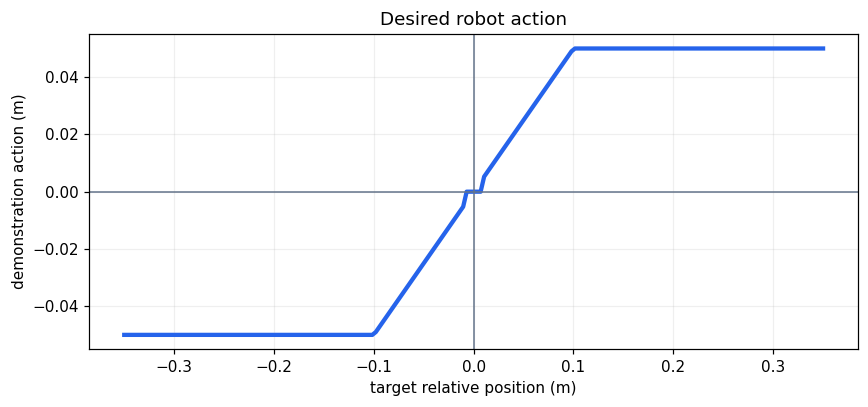

In [2]:
def desired_action(distance, contact):  # 定义教学任务中的示范动作规则
    proportional_action = 0.5 * distance  # 先让动作大小与目标距离成比例
    limited_action = np.clip(proportional_action, -0.05, 0.05)  # 把单步动作限制在正负 0.05 米以内
    should_stop = (np.abs(distance) < 0.01) | (contact > 0.5)  # 判断是否已经接近目标或发生接触
    return np.where(should_stop, 0.0, limited_action)  # 需要停止时输出零动作，否则输出限速动作

distances = np.linspace(-0.35, 0.35, 201)  # 生成从目标左侧到右侧的一系列相对位置
contacts = np.zeros_like(distances)  # 假设这组位置都还没有发生接触
target_actions = desired_action(distances, contacts)  # 计算每个位置对应的示范动作

fig, ax = plt.subplots(figsize=(8, 3.8))  # 创建用于显示目标动作关系的画布
ax.plot(distances, target_actions, color="#2563eb", linewidth=2.8)  # 画出目标距离与示范动作之间的关系
ax.axhline(0, color="#64748b", linewidth=1)  # 画出零动作参考线
ax.axvline(0, color="#64748b", linewidth=1)  # 画出目标正好位于当前位置的参考线
ax.set_title("Desired robot action")  # 设置图像标题
ax.set_xlabel("target relative position (m)")  # 标明横轴是目标相对位置
ax.set_ylabel("demonstration action (m)")  # 标明纵轴是示范动作
ax.grid(alpha=0.2)  # 添加浅色网格帮助读取数值
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示任务希望模型学习的动作曲线

### 怎样理解这个结果

横轴表示目标相对末端的位置，纵轴表示示范者希望机器人执行的单步位移。曲线左侧为负，表示目标在左侧时末端应向左运动；右侧为正，表示目标在右侧时应向右运动。两端变平是动作限速，原点附近变为零是到达后的停止区域。模型后续不是记住这张图，而是通过参数近似这条输入—输出关系。

## 2. 单一线性模型为什么不够

线性模型只能产生一条直线。下面让它用最小二乘方法拟合刚才的示范动作，再观察它在哪些区域出现系统性误差。

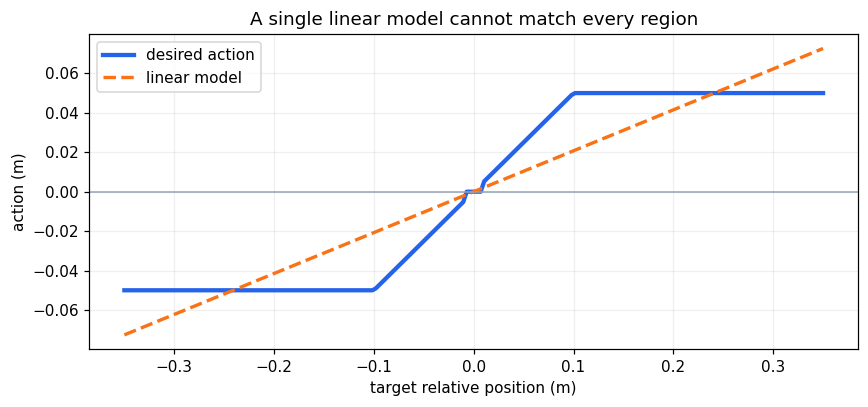

In [3]:
linear_weight, linear_bias = np.polyfit(distances, target_actions, deg=1)  # 求出最接近示范数据的一条直线
linear_predictions = linear_weight * distances + linear_bias  # 使用线性参数计算所有位置的动作预测

fig, ax = plt.subplots(figsize=(8, 3.8))  # 创建用于比较两种关系的画布
ax.plot(distances, target_actions, color="#2563eb", linewidth=2.8, label="desired action")  # 画出真实希望学习的非线性关系
ax.plot(distances, linear_predictions, color="#f97316", linewidth=2.2, linestyle="--", label="linear model")  # 画出线性模型的最佳拟合结果
ax.axhline(0, color="#94a3b8", linewidth=1)  # 添加零动作参考线
ax.set_title("A single linear model cannot match every region")  # 设置图像标题
ax.set_xlabel("target relative position (m)")  # 标明横轴是目标相对位置
ax.set_ylabel("action (m)")  # 标明纵轴是动作大小
ax.legend()  # 显示两条曲线各自的含义
ax.grid(alpha=0.2)  # 添加浅色网格方便比较误差
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示线性模型与目标动作的比较

### 怎样理解这个结果

橙色虚线只能以固定斜率变化。它为了兼顾全部数据，在远距离区域超过希望的限速动作，在原点附近又无法形成清晰的停止区。蓝色曲线则需要在不同位置采用不同规律。多层网络加入激活函数后，可以把输入空间分成若干区域，再组合出这种分段关系。

## 3. ReLU 怎样改变线性层的输出

ReLU 的计算规则是 `max(0, x)`：负输入变为 0，正输入保持不变。下面直接画出它的输入输出关系。

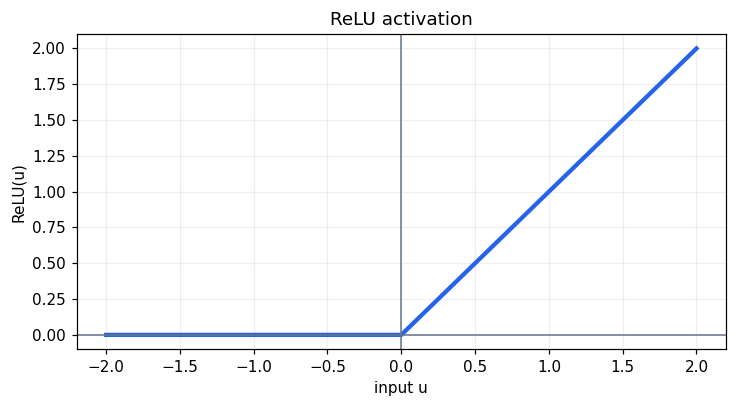

In [4]:
def relu(values):  # 定义 ReLU 激活函数
    return np.maximum(0.0, values)  # 把负数变为零并保留非负数

activation_inputs = np.linspace(-2.0, 2.0, 201)  # 生成覆盖负数和正数的输入
relu_outputs = relu(activation_inputs)  # 计算每个输入经过 ReLU 后的结果

fig, ax = plt.subplots(figsize=(6.8, 3.8))  # 创建用于显示 ReLU 的画布
ax.plot(activation_inputs, relu_outputs, color="#2563eb", linewidth=2.8)  # 画出 ReLU 曲线
ax.axhline(0, color="#64748b", linewidth=1)  # 画出输出为零的参考线
ax.axvline(0, color="#64748b", linewidth=1)  # 画出输入为零的分界线
ax.set_title("ReLU activation")  # 设置图像标题
ax.set_xlabel("input u")  # 标明横轴是线性层输出
ax.set_ylabel("ReLU(u)")  # 标明纵轴是激活后的结果
ax.grid(alpha=0.2)  # 添加浅色网格帮助读取函数值
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示 ReLU 输入输出曲线

### 怎样理解这个结果

原点左侧的输出全部为 0，可以理解为当前神经元暂时关闭；原点右侧的输出等于输入，可以理解为当前通路被激活。不同隐藏单元使用不同权重和偏置，因此会在不同输入区域开启。多个这样的响应经过后续层组合，就不再局限于一条直线。需要注意，ReLU 没有把正值限制到 1，它也不是概率函数。

## 4. 比较几种常用激活函数

激活函数并非只有 ReLU。下面在相同输入范围内比较 ReLU、Sigmoid、Tanh 和 SiLU 的形状。

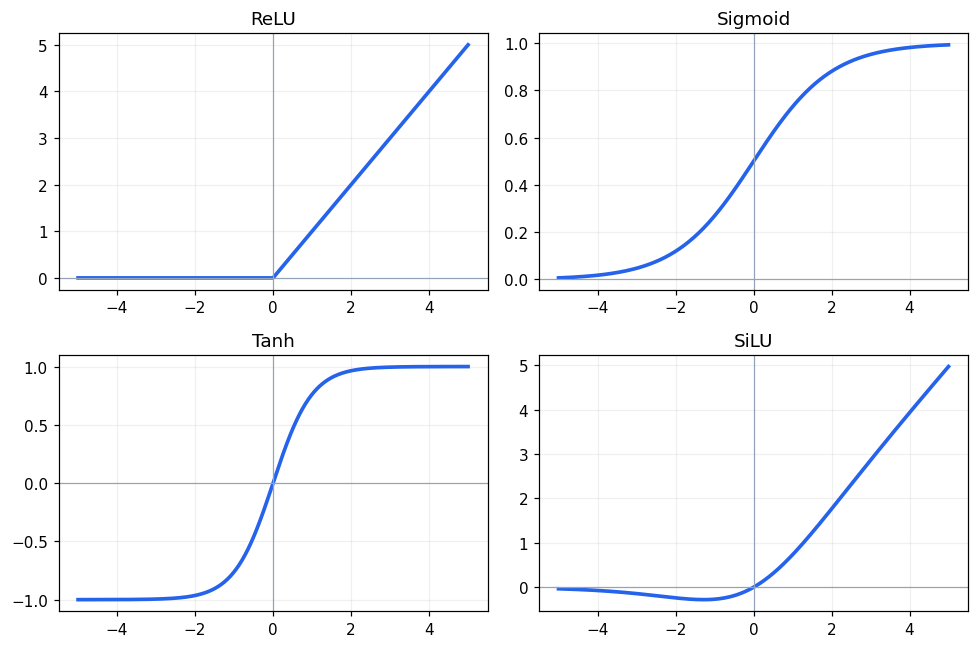

In [5]:
def sigmoid(values):  # 定义把数值压缩到零和一之间的 Sigmoid 函数
    return 1.0 / (1.0 + np.exp(-values))  # 按照 Sigmoid 公式计算输出

def silu(values):  # 定义 SiLU 或 Swish 激活函数
    return values * sigmoid(values)  # 用输入乘以对应的 Sigmoid 门控值

function_inputs = np.linspace(-5.0, 5.0, 401)  # 为四种函数生成相同的输入范围
activation_functions = [("ReLU", relu), ("Sigmoid", sigmoid), ("Tanh", np.tanh), ("SiLU", silu)]  # 整理需要比较的函数
fig, axes = plt.subplots(2, 2, figsize=(9, 6))  # 创建四个结构一致的小图
for ax, (name, function) in zip(axes.ravel(), activation_functions):  # 依次遍历子图和激活函数
    ax.plot(function_inputs, function(function_inputs), color="#2563eb", linewidth=2.4)  # 画出当前激活函数的曲线
    ax.axhline(0, color="#94a3b8", linewidth=0.8)  # 添加水平零线
    ax.axvline(0, color="#94a3b8", linewidth=0.8)  # 添加垂直零线
    ax.set_title(name)  # 在子图上写出激活函数名称
    ax.grid(alpha=0.18)  # 添加浅色网格帮助比较形状
plt.tight_layout()  # 自动调整四个子图的间距
plt.show()  # 显示四种激活函数

### 怎样理解这个结果

ReLU 计算简单，常用于隐藏层；Sigmoid 把输出限制在 0 到 1，适合二分类概率或门控值；Tanh 输出位于 -1 到 1，可表示有正负方向的有界量；SiLU 是平滑函数，负输入仍可保留小响应，常见于现代视觉和生成模型。选择激活函数取决于它位于隐藏层还是输出层，以及输出需要满足什么范围，不能只根据曲线是否平滑决定。

## 5. 完成一次两层网络的前向计算

现在使用课程正文中的小型网络。输入包含目标水平距离和接触信号，隐藏层包含两个 ReLU 单元，输出是水平位移动作。这里暂时手工指定参数，下一份练习再让参数从数据中学习。

In [6]:
robot_input = np.array([0.12, 0.0])  # 表示目标在右侧 0.12 米且尚未接触
W1 = np.array([[4.0, -1.0], [-4.0, -1.0]])  # 设置输入层到两个隐藏单元的权重
b1 = np.array([0.0, 0.0])  # 设置隐藏层偏置
W2 = np.array([[0.1, -0.1]])  # 设置两个隐藏响应到水平动作的权重
b2 = np.array([0.0])  # 设置输出层偏置

hidden_linear = W1 @ robot_input + b1  # 先计算隐藏层激活前的线性结果
hidden_activated = relu(hidden_linear)  # 使用 ReLU 关闭负响应并保留正响应
predicted_action = W2 @ hidden_activated + b2  # 把隐藏响应组合成最终动作

print("输入 [目标距离, 接触信号]：", robot_input)  # 输出本次前向计算使用的输入
print("隐藏层线性结果：", hidden_linear)  # 输出 ReLU 之前的两个数值
print("ReLU 后的隐藏响应：", hidden_activated)  # 输出被开启和关闭的隐藏单元
print("预测水平动作：", predicted_action[0], "米")  # 输出网络最终预测的位移动作

输入 [目标距离, 接触信号]： [0.12 0.  ]
隐藏层线性结果： [ 0.48 -0.48]
ReLU 后的隐藏响应： [0.48 0.  ]
预测水平动作： 0.048 米


### 怎样理解这个结果

输入首先被两个隐藏单元从不同方向观察。第一个线性结果为正，表示“向右”通路被开启；第二个结果为负，经 ReLU 后变为 0，表示“向左”通路关闭。输出层最终给出约 +0.048 米，正号表示向右。这就是一次完整前向计算，期间参数没有发生任何变化。

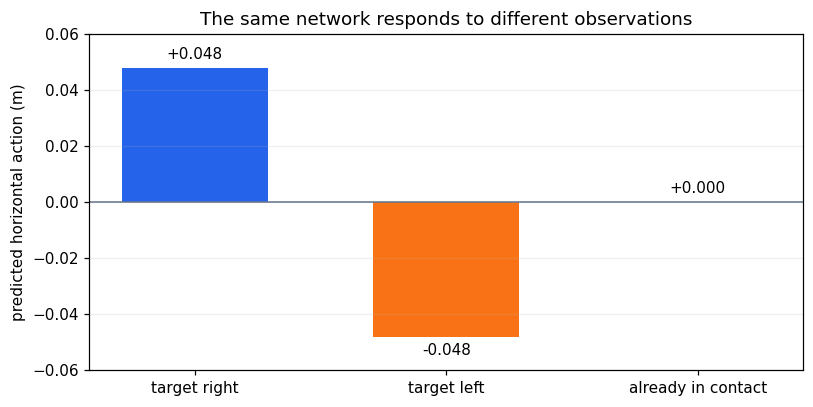

In [7]:
case_names = ["target right", "target left", "already in contact"]  # 为三种输入情形准备标签
case_inputs = np.array([[0.12, 0.0], [-0.12, 0.0], [0.12, 1.0]])  # 构造右侧、左侧和已接触三条观测
case_hidden_linear = case_inputs @ W1.T + b1  # 同时计算三条观测的隐藏层线性结果
case_hidden_activated = relu(case_hidden_linear)  # 对所有隐藏结果应用 ReLU
case_actions = (case_hidden_activated @ W2.T + b2).ravel()  # 计算并整理三种情形的动作预测

fig, ax = plt.subplots(figsize=(7.5, 3.8))  # 创建用于比较三种动作的画布
bars = ax.bar(case_names, case_actions, color=["#2563eb", "#f97316", "#16a34a"], width=0.58)  # 用柱子显示动作方向和大小
ax.axhline(0, color="#64748b", linewidth=1)  # 添加正负动作的分界线
ax.set_title("The same network responds to different observations")  # 设置图像标题
ax.set_ylabel("predicted horizontal action (m)")  # 标明纵轴是预测水平动作
ax.set_ylim(-0.06, 0.06)  # 使用对称范围便于比较左右方向
ax.bar_label(bars, labels=[f"{value:+.3f}" for value in case_actions], padding=4)  # 在柱子旁标出带方向的动作数值
ax.grid(axis="y", alpha=0.2)  # 添加水平网格方便比较动作大小
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示三种观测对应的网络输出

### 怎样理解这个结果

目标在右侧时动作是正数，目标在左侧时动作是负数；位置相同但接触信号变为 1 后，两个方向通路都被抑制，动作变为 0。这个结果说明输出不仅由目标位置决定，也会随其他观测改变。真实网络的参数不由人设计，而是通过许多示范样本的误差逐步学习。

## 练习与小结

1. 把前向计算中的目标距离从 `0.12` 改为 `0.03`，观察预测动作怎样变化。
2. 修改 `W2` 中的两个权重，观察左右动作的大小和方向是否仍然合理。
3. 在激活函数比较图中加入 `GELU` 的近似实现，观察它与 SiLU 的差异。

本练习从机器人任务需要的动作关系出发，展示了线性模型的局限、ReLU 的开关作用、常用激活函数的形状，以及两层网络的一次完整前向计算。下一份练习将保留相同任务，让参数通过损失和梯度自动更新。